In [5]:
import pandas as pd

In [16]:
 pd.read_csv('Cleaned_Data')

,Unnamed: 0,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,0,CUST4371,Paul Wilson,m,52.0,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,india
1,1,CUST5957,Jason Thomas,m,51.0,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,2,CUST3754,Brittney Martinez,f,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,india
3,3,CUST2934,Brenda Pierce,female,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,4,CUST5683,Matthew Carroll,f,41.0,chennai,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,india
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,10193,CUST6352,Isaiah Terry,f,26.0,kolkata,2023-03-04,2025-06-30,43655.0,6.0,lopezleonard@example.net,7694723210,india
8996,10194,CUST6146,Cody Thompson,f,40.0,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,india
8997,10195,CUST10767,Robert Lewis,female,35.0,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,india
8998,10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,india


In [23]:
#CHANGING DATA COLUMN TO DATETIME
df['Signup_Date']=pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date']=pd.to_datetime(df['Last_Purchase_Date'])


In [24]:
df.dtypes

Unnamed: 0                     int64
Customer_ID                   object
Name                          object
Gender                        object
Age                          float64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score               float64
Email                         object
Phone_Number                   int64
Country                       object
dtype: object

Univariate Analysis

In [26]:
#summary statistics for numerical column

numeric_cols = ['Age','Purchase_Amount','Feedback_Score']

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%']-summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics:\n ")
summary


Numeric Summary Statistics:
 


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,8157.0,43.644722,16.093943,3.0,31.0,43.0,56.00,250.0,43.0,25.00,1.779280
Purchase_Amount,8094.0,29620.796639,222179.326387,-500.0,12265.0,24268.0,37110.75,9999999.0,24268.0,24845.75,44.676488
Feedback_Score,8113.0,5.481326,2.863371,1.0,3.0,6.0,8.00,10.0,6.0,5.00,0.002732


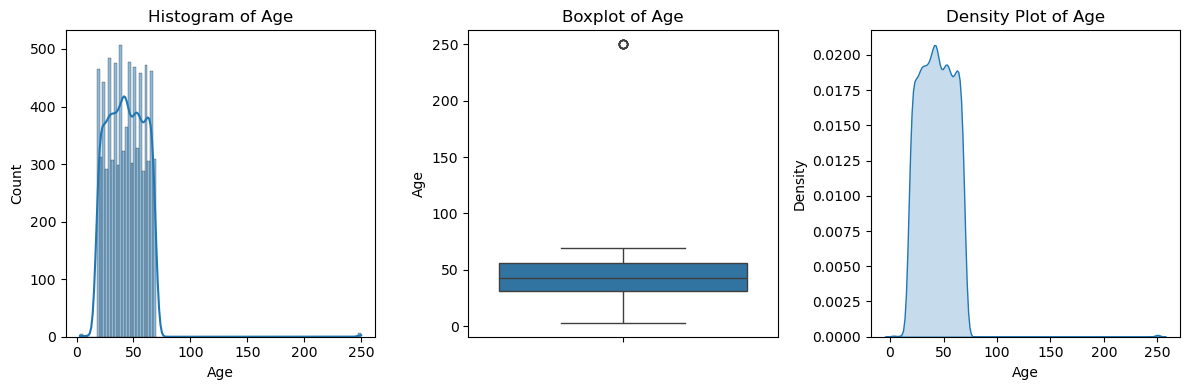

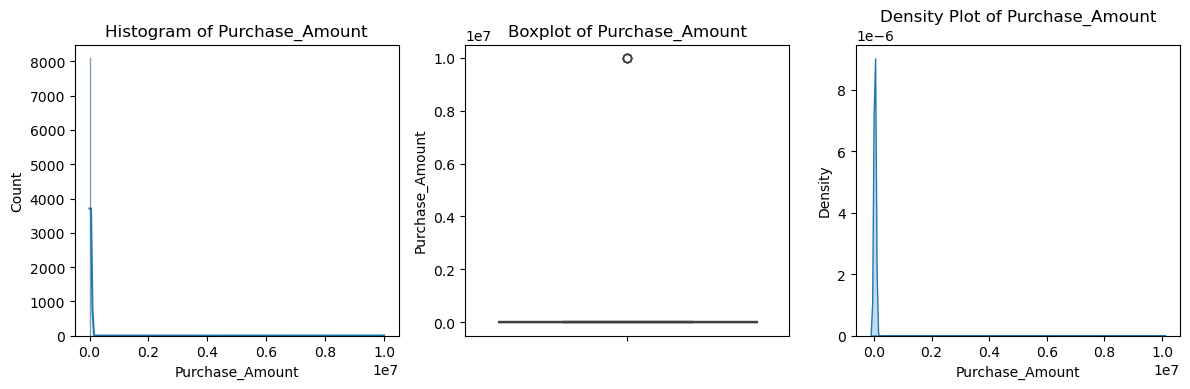

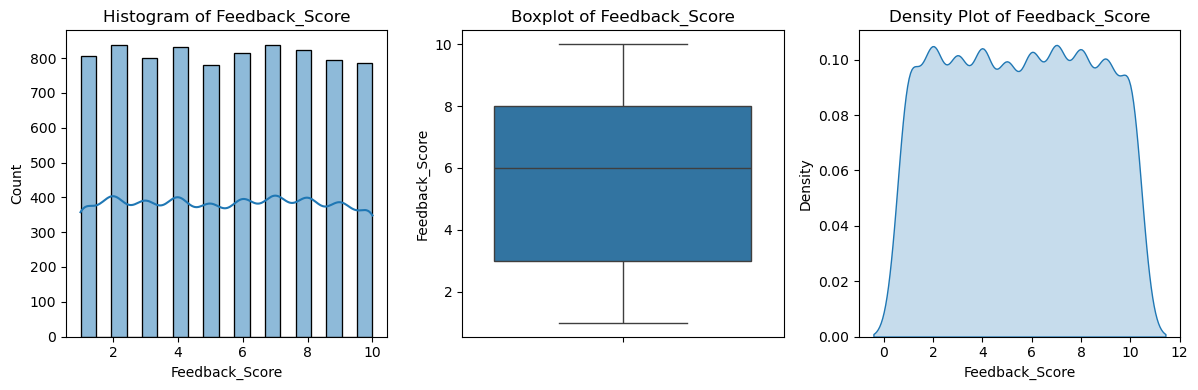

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram, Boxplot, and Density Plot for Numerical Columns
for col in numeric_cols:

    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    # Density Plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()


Frequency Counts for Gender:

Gender
m         2073
f         2065
male      1982
female    1971
Name: count, dtype: int64


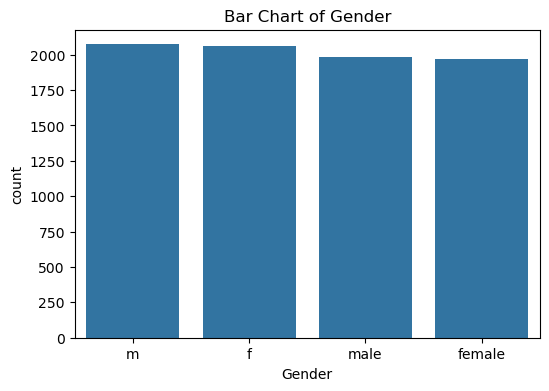


Frequency Counts for City:

City
mumbai       1360
chennai      1357
kolkata      1352
delhi        1352
hyderabad    1337
bangalore    1337
Name: count, dtype: int64


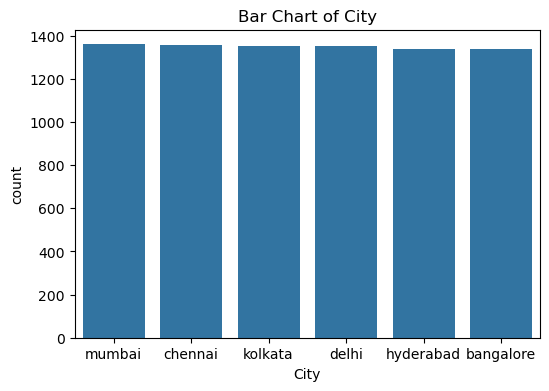

In [28]:
 # Frequency Count for Categorical Columns

cat_cols = ['Gender', 'City']

for index, col in enumerate(cat_cols):

    print(f"\nFrequency Counts for {col}:\n")
    print(df[col].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )

    plt.title(f'Bar Chart of {col}')
    plt.show()


Date Range for Signup_Date: 2020-10-08 00:00:00 to 2025-10-08 00:00:00
Time Span: 1826 days

Date Range for Last_Purchase_Date: 2024-10-08 00:00:00 to 2025-10-08 00:00:00
Time Span: 365 days


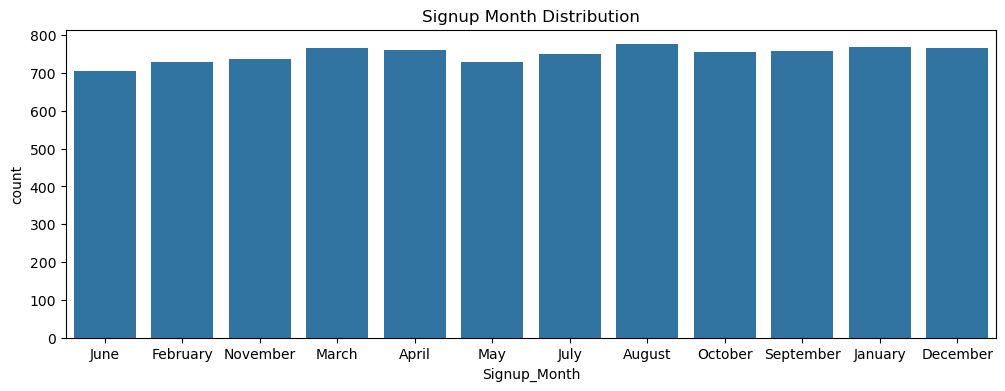

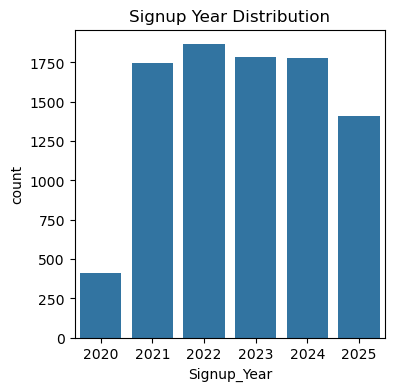

In [29]:
# Date Columns Analysis

date_cols = ['Signup_Date', 'Last_Purchase_Date']

for col in date_cols:
    print(f"\nDate Range for {col}: {df[col].min()} to {df[col].max()}")
    print(f"Time Span: {(df[col].max() - df[col].min()).days} days")

# Month Distribution

plt.figure(figsize=(12, 4))

df['Signup_Month'] = df['Signup_Date'].dt.month_name()

sns.countplot(x='Signup_Month', data=df)

plt.title('Signup Month Distribution')
plt.show()

# Year Distribution

plt.figure(figsize=(4, 4))

df['Signup_Year'] = df['Signup_Date'].dt.year

sns.countplot(x='Signup_Year', data=df)

plt.title('Signup Year Distribution')
plt.show()

In [31]:
def time_granularity(series):
    diffs = series.sort_values().diff().dropna().dt.days
    return diffs.describe()

In [32]:
time_granularity(df['Last_Purchase_Date'])

count    8999.00000
mean        0.04056
std         0.19728
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max         1.00000
Name: Last_Purchase_Date, dtype: float64

In [35]:
df['Last_Purchase_Date'].sort_values().diff().value_counts()

Last_Purchase_Date
0 days    8634
1 days     365
Name: count, dtype: int64

In [36]:
time_granularity(df['Signup_Date'])


count    8999.000000
mean        0.202911
std         0.405766
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: Signup_Date, dtype: float64

In [37]:
df['Signup_Date'].sort_values().diff().value_counts()

Signup_Date
0 days    7185
1 days    1803
2 days      10
3 days       1
Name: count, dtype: int64

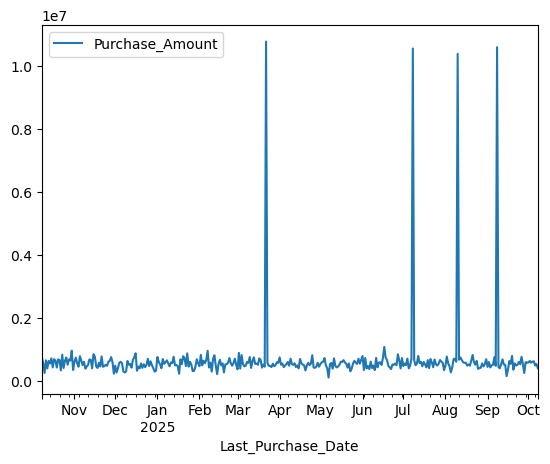

In [38]:
df.groupby('Last_Purchase_Date')[['Purchase_Amount']].sum().plot()
plt.show()

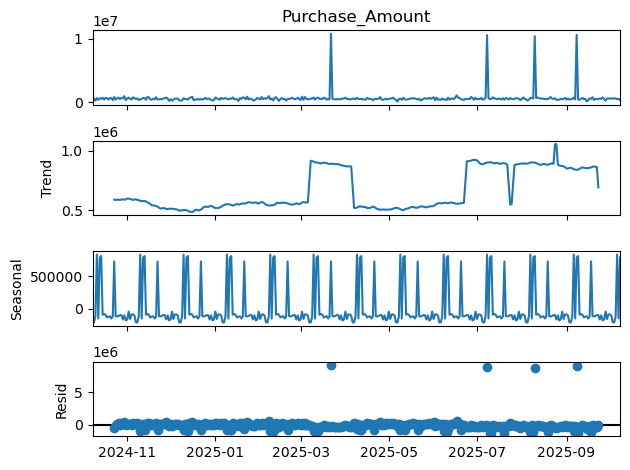

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate daily purchase amount
df_daily = df.groupby('Last_Purchase_Date')['Purchase_Amount'].sum()

# Seasonal decomposition
result = seasonal_decompose(
    df_daily,
    model='additive',
    period=30
)

# Plot decomposition
result.plot()
plt.show()

In [41]:
  # Extract Day and Month from Last Purchase Date

df["day"] = df["Last_Purchase_Date"].dt.day
df["month"] = df["Last_Purchase_Date"].dt.month

# Create Pivot Table for Heatmap

heatmap_data = df.pivot_table(
    index="day",
    columns="month",
    values="Purchase_Amount",
    aggfunc="mean"
)

# Display the Pivot Table
heatmap_data

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,27995.777778,23129.200000,20265.555556,24011.645161,25297.571429,26212.800000,27651.176471,22131.454545,22030.700000,22372.769231,20807.551724,25284.526316
2,27350.863636,31649.269231,26044.676471,25624.050000,24510.958333,21350.187500,23722.000000,25699.166667,25849.434783,33209.052632,28309.153846,21919.083333
3,25044.428571,27193.111111,21553.277778,26040.476190,26328.043478,24123.400000,26219.052632,26299.523810,24919.705882,27373.904762,22310.480000,22372.055556
4,28453.857143,25522.480000,31437.115385,20659.285714,24835.000000,23136.529412,22006.375000,28741.062500,30696.875000,26553.043478,26312.941176,28490.450000
5,26647.192308,27948.600000,22081.750000,27044.833333,27060.555556,23297.000000,23252.647059,22337.500000,25220.150000,24727.080000,27040.689655,25140.833333
6,21512.120000,26500.040000,24019.052632,23067.956522,21110.473684,23363.500000,21809.227273,20409.952381,24119.580645,26972.222222,26537.541667,29291.052632
7,32527.777778,28060.911765,28327.588235,22961.538462,11285.444444,25416.000000,24926.571429,27563.720000,23675.300000,27949.894737,20798.250000,24510.916667
8,29459.500000,19941.380952,27311.545455,31885.666667,21767.375000,25301.250000,480186.681818,26876.230769,407864.500000,25257.195652,26322.086957,20345.000000
9,23127.208333,23045.240000,21258.555556,26023.666667,22667.920000,26988.555556,27224.791667,28789.047619,33727.615385,24009.782609,20269.894737,21190.857143


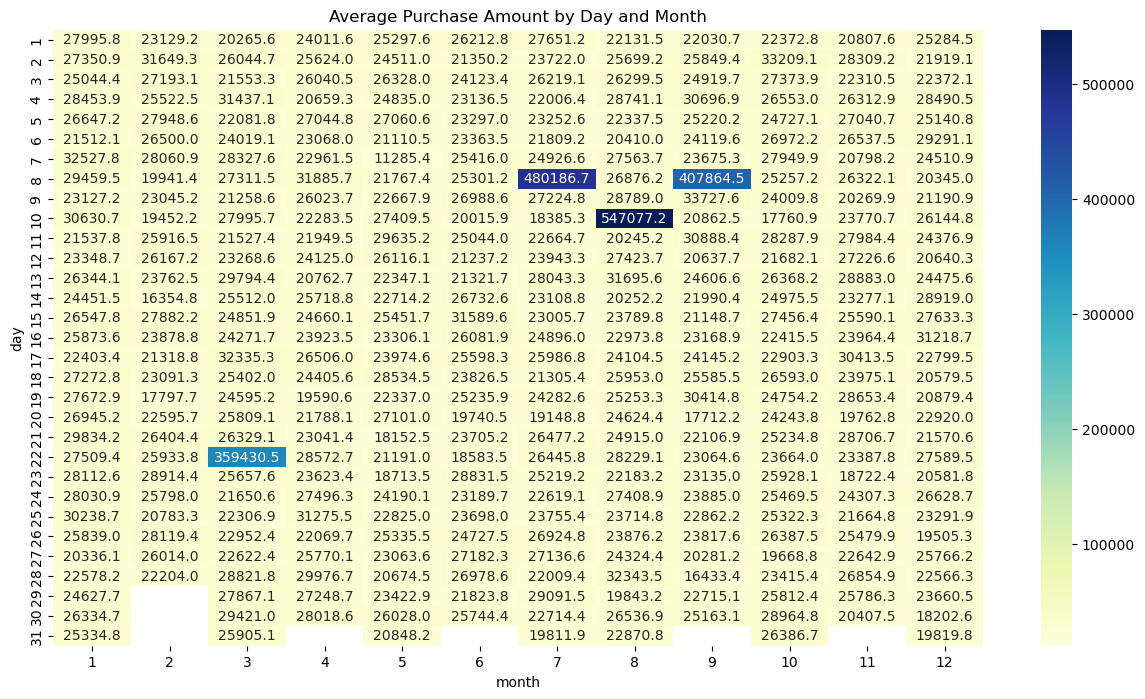

In [44]:
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Purchase Amount by Day and Month")
plt.show()